In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, vonmises_fisher
import seaborn as sns
import sys
import glob
from tqdm import trange 

In [4]:
results = "../results/figure4/*.csv"

In [5]:
dfs = list()
for f in glob.glob(results):
    dfs.append(pd.read_csv(f).rename({"Unnamed: 0": "measure"}, axis=1))

In [7]:
all_dfs = pd.concat(dfs)
all_dfs = all_dfs[all_dfs["measure"].isin(["betweenness", "degree", "closeness", "clustering", "pagerank"])].copy()

In [ ]:
all_dfs.columns = ['measure', 'raw', 'BOSPERRUS', 'SERN', 'on crop vs. SERN values', 'cap_radius', 'graph_type', 'coord_type', 'n', 'k', 'radius']

In [22]:
all_dfs["radius"].fillna(0, inplace=True)
all_dfs["k"].fillna(0, inplace=True)
all_dfs["param"] = all_dfs["k"] + all_dfs["radius"]

/tmp/ipykernel_3906944/2327122098.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_dfs["radius"].fillna(0, inplace=True)
/tmp/ipykernel_3906944/2327122098.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [23]:
degree = all_dfs[all_dfs["measure"] == "degree"]

In [24]:
degree[["coord_type", "graph_type", "cap_radius", "param"]].value_counts().sort_index()

coord_type   graph_type  cap_radius  param
kappa=1      delaunay    1           0.00     300
                         2           0.00     300
             knn         1           5.00     300
                                     10.00    300
                                     15.00    300
                         2           5.00     300
                                     10.00    300
                                     15.00    300
             rnn         1           0.05     300
                                     0.10     300
                                     0.15     300
                         2           0.05     300
                                     0.10     300
                                     0.15     300
kappa=1,3,5  delaunay    1           0.00     300
                         2           0.00     300
             knn         1           5.00     300
                                     10.00    300
                                     15.00    300
       

In [26]:
12600/3

4200.0

In [ ]:
degree[["coord_type", ]].value_counts()

In [ ]:
all_dfs["BOSPERRUS"] = np.abs(all_dfs["BOSPERRUS"])
all_dfs["SERN"] = np.abs(all_dfs["SERN"])
all_dfs["raw"] = np.abs(all_dfs["raw"])

In [ ]:
best_corr = all_dfs[["BOSPERRUS", "SERN", "raw"]].idxmax(axis=1)
all_dfs["highest correlation"] = best_corr

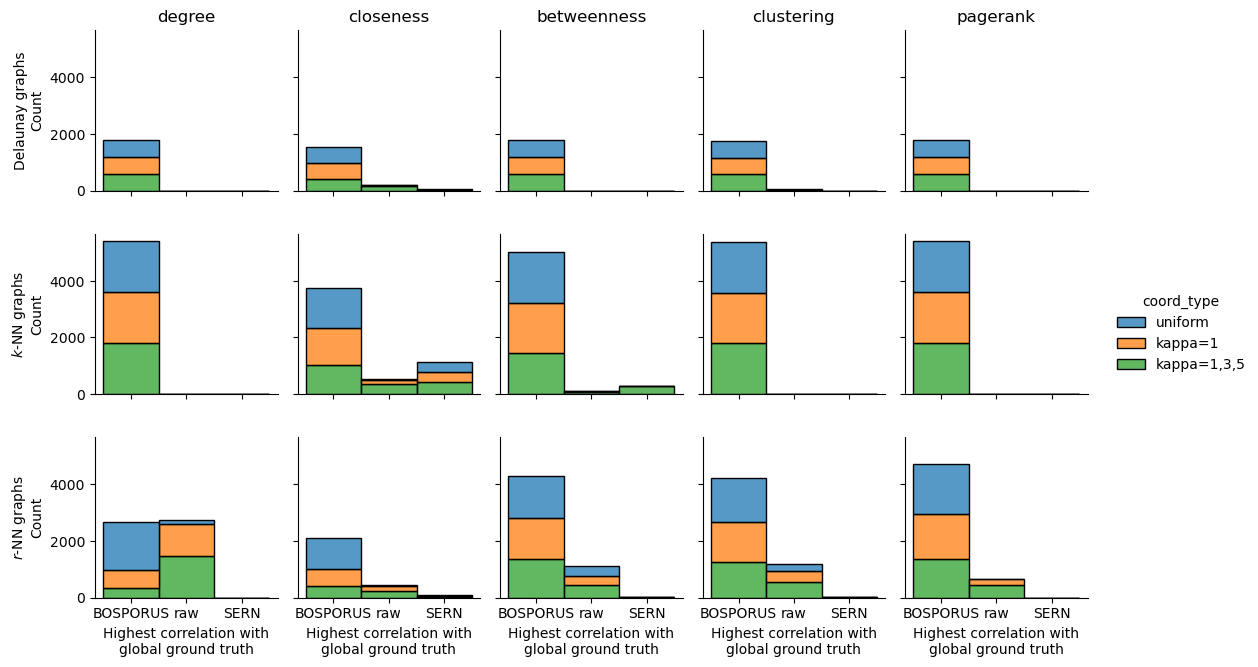

In [11]:
g = sns.displot(all_dfs.reset_index(), hue="coord_type", x="highest correlation", row="graph_type", col="measure", height=2.2, aspect=1, multiple="stack")
for i, ax in enumerate(g.axes.flat):
    original_title = ax.get_title()

    if i >= 5:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])

    if i % 5 == 0:
        if i == 0:
            ax.set_ylabel(f"Delaunay graphs\nCount")
        if i == 5:
            ax.set_ylabel(f"$k$-NN graphs\nCount")
        if i == 10:
            ax.set_ylabel(f"$r$-NN graphs\nCount")

    if i >= 10 :
        ax.set_xlabel(f"Highest correlation with\nglobal ground truth")
plt.savefig("correlations_on_sphere.pdf", bbox_inches="tight")